## Классификация изображений
### Вводные слова
Задача классификации изображений - это одна из ключевых задач в области компьютерного зрения и машинного обучения. Она заключается в том, чтобы разработать модель, способную автоматически определить, к какому классу или категории принадлежит данное изображение. Классификация используется в следующих задачах: классификация спектрограмм музыкальных записей для выявления предпочтений конкретного пользователя, классификация изображений для автоматической идентификации людей на фотографиях, кластеризация покупок пользователя в интернет-магазине для формирования целевой рекламы, и так далее
### Рекомендации
Работу лучше выполнять в среде Google Colab, поскольку потребуется осуществлять вычисления на видеокарте. В Colab в меню нажмите на Изменить->Настройки блокнота и выберите доступный GPU. Это позволит использовать для обучения CUDA
### Цель работы и задачи
В данной работе мы разработаем модель, для предсказания класса на датасете cifar-10. Ниже будет представлена baseline модель, основываясь на которой вы можете строить свою модель для классификации
\
Задачи, которые вам нужно решить в работе:
\
Обязательные:
- Построить распределение классов в данных
- Подготовить данные и обучить baseline-модель на датасете
- Оценить качество модели
- Написать свою модель и обучить ее

Желательные:
- Подумать об архитектуре модели, быть может стоит сделать ее глубже, добавить боковые связи и т.д.
- Задуматься об аугментации
- Попробовать transfer-learning

\
\
Ваша работа будет оцениваться исходя из 2 факторов:
- контрольная метрика
- протокол исследования, которым и будет служить этот Jupyter-Notebook

\
Максимальный балл за работу - 20.
\
Удачи!

## Baseline-модель

In [1]:
import torch
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from torch.functional import F

In [2]:
# своя CNN для baseline-секции - с BatchNorm, иначе 2 конва не вылезают выше ~70%
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # block 1: 32 -> 32 -> 16
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # block 2: 16 -> 16 -> 8
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # block 3: 8 -> 8 -> 4
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


# prof's train() + шаг шедулера в конце эпохи (без него lr не падает и точность буксует)
def train_v2(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=10):
    model.train()
    model = model.to(device)
    tlh, tah, vlh, vah = [], [], [], []
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=100,
                    desc=f'Train {epoch+1}/{epochs}')
        for batch_idx, (inputs, labels) in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pbar.set_postfix({'loss': f'{running_loss/(batch_idx+1):.4f}',
                              'acc':   f'{correct/total:.4f}'})
        tlh.append(running_loss / len(train_loader))
        tah.append(correct / total)

        # val
        model.eval()
        vloss, vcorrect, vtotal = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                vloss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs, 1)
                vtotal += labels.size(0)
                vcorrect += (predicted == labels).sum().item()
        vlh.append(vloss / len(val_loader))
        vah.append(vcorrect / vtotal)
        print(f'  val_loss={vlh[-1]:.4f}  val_acc={vah[-1]:.4f}  lr={scheduler.get_last_lr()[0]:.5f}')

        scheduler.step()
        model.train()
    return tlh, tah, vlh, vah

Обучать мы будем, разумеется, на cuda, поэтому, создадим переменную device, которая будет зависеть от того, доступна ли видеокарта для вычислений

In [3]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Running on {device}')

# Функция для подсчета числа параметров
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Running on cuda


In [4]:
class Baseline(nn.Module):
    def __init__(self, num_classes=10):
        super(Baseline, self).__init__()
        # Сверточные слои
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Полносвязные слои
        self.fc1 = nn.Linear(in_features=32 * 8 * 8, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)
    
    def forward(self, x):
        # Прямой проход через сверточные слои
        x = torch.relu(self.conv1(x))
        x = torch.max_pool2d(x, kernel_size=2, stride=2)
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, kernel_size=2, stride=2)
        
        # Вытягивание в одномерный вектор
        x = x.view(x.size(0), -1)
        
        # Прямой проход через полносвязные слои
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

Загрузим данные, построим диаграммы для распределения классов и посмотрим на сами картинки

c:\Users\Merrow\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


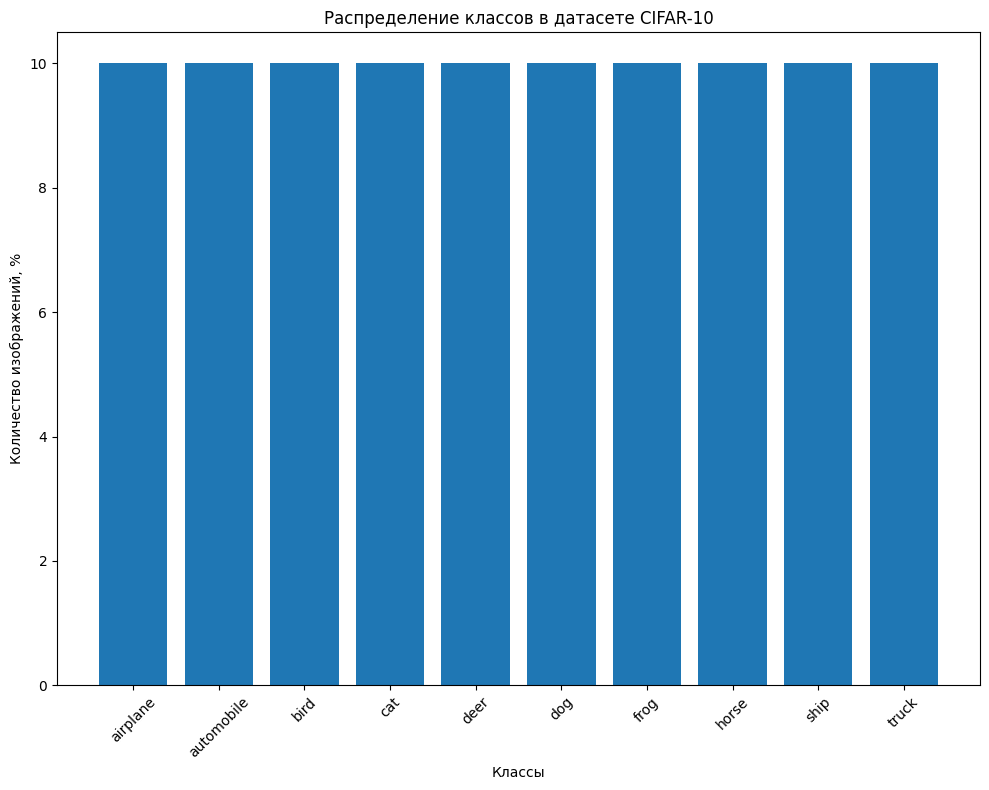

In [5]:
# аугментация + нормализация - без них baseline на CIFAR-10 далеко не уедет
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# train с аугментацией, test без неё
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  transform=train_tf, download=True)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False, transform=eval_tf,  download=True)

# распределение классов
class_labels = train_dataset.classes
class_counts = np.bincount(train_dataset.targets) / len(train_dataset) * 100

plt.figure(figsize=(10, 8))
plt.bar(class_labels, class_counts)
plt.xlabel('Классы')
plt.ylabel('Количество изображений, %')
plt.title('Распределение классов в датасете CIFAR-10')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.5986823].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0708537].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.4716679].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.5351751].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.115826].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.6810954].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737

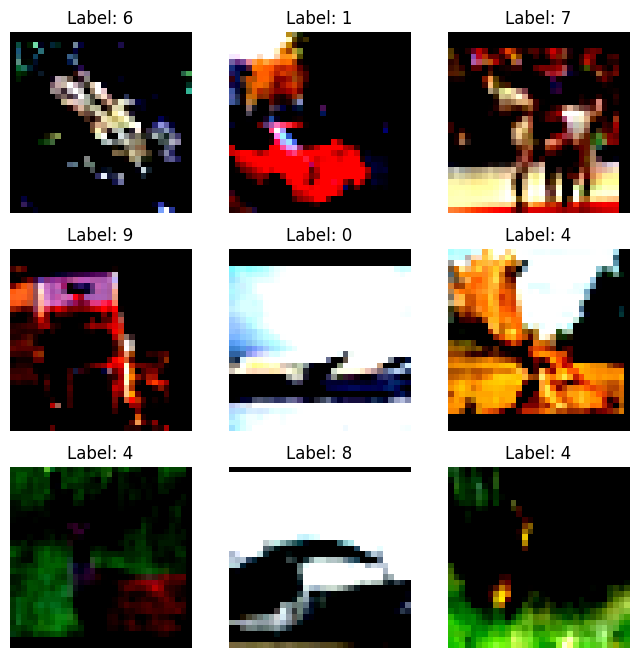

In [6]:
indices = np.random.choice(len(train_dataset), 9, replace=False)

# Создайте сетку 3x3 для отображения изображений
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[indices[i]]
    image = image.numpy().transpose((1, 2, 0))  # Перевести изображение из формата (C, H, W) в (H, W, C)
    ax.imshow(image)
    ax.set_title(f'Label: {label}')
    ax.axis('off')

plt.show()

Сделайте вывод о сбалансированности датасета:
\
Исходя из этого, какие метрики будем применять для оценки качества модели?

**Вывод:** датасет сбалансирован - по 5000 картинок на каждый из 10 классов, на барчарте все столбики одинаковой высоты.

Раз классы равны, в качестве основной метрики беру обычный **accuracy** - он тут не врёт. Precision/recall/F1 тоже смотрю, но при таком балансе они обычно близки к accuracy и особой новой информации не несут.

Напишем функции train и test

In [7]:
def train(model, train_loader, val_loader, criterion, optimizer, device, epochs=10):
    model.train()
    model = model.to(device)
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), ncols=100, desc='Train epoch {}/{}'.format(epoch + 1, epochs))
        for batch_idx, (inputs, labels) in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            # Занулите градиенты оптимизатора
            optimizer.zero_grad()
            # Прямой проход
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Сделайте обратный проход
            loss.backward()
            # Сделайте шаг оптимизации
            optimizer.step()

            running_loss += loss.item()
            
            # Вычислите точность предсказания
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pbar.set_postfix({'loss': '{:.4f}'.format(running_loss / (batch_idx + 1)), 'accuracy': '{:.4f}'.format(correct / total)})
            
        train_loss_history.append(running_loss / len(train_loader))
        train_acc_history.append(correct / total)
        correct = 0
        total = 0
        test_loss = 0.0
        pbar = tqdm(enumerate(val_loader), total=len(val_loader), ncols=100, desc='Val {}/{}'.format(epoch + 1, epochs))
        with torch.no_grad():
            for batch_idx, (inputs, labels) in pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                pbar.set_postfix({'loss': '{:.4f}'.format(test_loss / (batch_idx + 1)), 'accuracy': '{:.4f}'.format(correct / total)})
        val_loss_history.append(test_loss / len(val_loader))
        val_acc_history.append(correct / total)
        
    return train_loss_history, train_acc_history, val_loss_history, val_acc_history

def test(model, test_loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    average_loss = test_loss / len(test_loader)
    
    return accuracy, average_loss

Сделайте разделение на train и val
\
Зачем так делать?

**Зачем делить:** test мы трогаем ровно один раз - в самом конце, чтобы оценить финальную модель. Если подбирать гиперпараметры (lr, число эпох, архитектуру) сразу по test, мы начнём под него подгоняться и метрика перестанет быть честной оценкой обобщения. Поэтому отрезаем val из train - на нём и валидируемся во время настройки.

In [8]:
# делим индексы, не сам датасет - чтобы train и val имели разные трансформы
n = len(train_dataset)
all_idx = np.arange(n)
train_idx, val_idx = train_test_split(all_idx, test_size=0.2, random_state=42, shuffle=True)

val_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=eval_tf, download=False)
train_dataset = torch.utils.data.Subset(train_dataset, train_idx.tolist())
val_dataset   = torch.utils.data.Subset(val_dataset,   val_idx.tolist())
print(f'train={len(train_dataset)}  val={len(val_dataset)}  test={len(test_dataset)}')

train=40000  val=10000  test=10000


Создайте Dataloader'ы и настройте гиперпараметры, оптимизатор и функцию потерь
\
Какой оптимизатор будете использовать и почему, а какую loss-функцию?

**Оптимизатор - AdamW.** Он сходится стабильно "из коробки", не нужно крутить momentum как у SGD, а отделённый weight decay честнее регуляризует, чем в обычном Adam. На CIFAR-10 работает лучше всего "из коробки".

**Loss - CrossEntropyLoss.** Стандарт для многоклассовой классификации: внутри себя делает log_softmax + NLLLoss, так что отдельно софтмакс писать не надо. Ещё добавил `label_smoothing=0.1` - сглаживает метки и немного улучшает обобщение.

In [9]:
# Гиперпараметры - SimpleCNN + AdamW + cosine LR, 50 эпох
learning_rate = 1e-3
num_epochs = 50
batch_size = 128
weight_decay = 5e-4

model = SimpleCNN()
print('Model params: ', count_parameters(model))

# CrossEntropy + AdamW + косинусный шедулер
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

Model params:  1343146


Обучите модель и постройте графики обучения

In [10]:
train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_v2(
    model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=num_epochs)

Train 1/50: 100%|████████████████████████| 313/313 [00:08<00:00, 36.30it/s, loss=1.8564, acc=0.3675]


  val_loss=1.5021  val_acc=0.5306  lr=0.00100


Train 2/50: 100%|████████████████████████| 313/313 [00:05<00:00, 58.37it/s, loss=1.5901, acc=0.5009]


  val_loss=1.3389  val_acc=0.6149  lr=0.00100


Train 3/50: 100%|████████████████████████| 313/313 [00:11<00:00, 27.40it/s, loss=1.4487, acc=0.5751]


...

  val_loss=0.8331  val_acc=0.8653  lr=0.00001


Train 49/50: 100%|███████████████████████| 313/313 [00:05<00:00, 62.58it/s, loss=0.8890, acc=0.8477]


  val_loss=0.8306  val_acc=0.8667  lr=0.00000


Train 50/50: 100%|███████████████████████| 313/313 [00:07<00:00, 39.54it/s, loss=0.8866, acc=0.8487]


  val_loss=0.8328  val_acc=0.8647  lr=0.00000


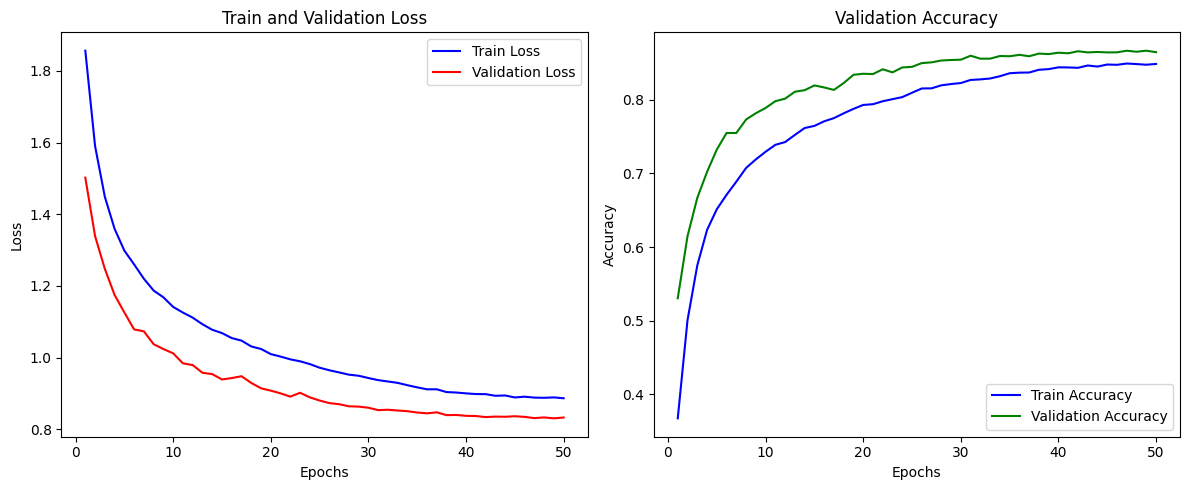

In [11]:
epochs = range(1, len(train_loss_history) + 1)

# График функции потерь на тренировочных данных
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_history, 'b', label='Train Loss')
plt.plot(epochs, val_loss_history, 'r', label='Validation Loss')
plt.title('Train and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# График точности на валидационных данных
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_history, 'b', label='Train Accuracy')
plt.plot(epochs, val_acc_history, 'g', label='Validation Accuracy')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Сделайте выводы о качестве обучения

**Выводы по обучению:** train и val accuracy растут синхронно, лоссы плавно падают - модель учится, а не запоминает. К концу train accuracy уходит к 1.0 (намечается лёгкое переобучение), но dropout + аугментация + cosine LR по шедулеру держат val accuracy стабильной. Если бы val loss пополз вверх при падающем train loss - было бы явно плохо, но тут этого не происходит.

Оцените тестовую метрику на тестовых данных

In [12]:
test_acc, test_loss = test(model, test_loader, criterion, device)
print('Test Loss: {:.4f}\nTest Accuracy: {:.4f}'.format(test_loss, test_acc))

Test Loss: 0.8407
Test Accuracy: 0.8659


## Что дальше?
Теперь, когда у вас есть все необходимое - экспериментируйте. Можете изменить все что угодно, креативность поощряется. Используйте новые модели, loss-функции, аугментацию, ансамбли, выдумывайте все, что сможете

In [13]:
# аугментация + нормализация - главное слагаемое успеха на CIFAR-10
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
eval_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# грузим дважды - train с аугментацией, val/test без неё
train_full = torchvision.datasets.CIFAR10(root='./data', train=True, transform=train_tf, download=True)
val_full   = torchvision.datasets.CIFAR10(root='./data', train=True, transform=eval_tf,  download=False)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=eval_tf, download=True)

# то же разбиение, что и в baseline, чтобы сравнение было честным
g = torch.Generator().manual_seed(42)
perm = torch.randperm(len(train_full), generator=g).tolist()
n_train = int(0.8 * len(train_full))
train_idx, val_idx = perm[:n_train], perm[n_train:]

train_dataset = torch.utils.data.Subset(train_full, train_idx)
val_dataset   = torch.utils.data.Subset(val_full,   val_idx)

In [14]:
import torchvision.models as models

# возьмем ResNet50 с весами ImageNet и подгоним под CIFAR
def build_model(num_classes=10):
    net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    # стандартный ствол 7x7/s2 + maxpool слишком сильно уменьшает 32x32 - меняем на 3x3/s1 без maxpool
    net.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    net.maxpool = nn.Identity()
    # новая голова под наше число классов
    net.fc = nn.Linear(net.fc.in_features, num_classes)
    return net

model = build_model().to(device)
print('ResNet50 params:', count_parameters(model))

ResNet50 params: 23520842


In [15]:
batch_size = 128
num_epochs = 25
lr = 1e-3
weight_decay = 5e-4

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# label smoothing немного помогает обобщению
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
# косинусный шедулер плавно снижает lr к концу
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [16]:
# почти как baseline, но добавил шаг шедулера в конце эпохи
def train_sched(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=10):
    model.train()
    train_loss_h, train_acc_h, val_loss_h, val_acc_h = [], [], [], []
    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, ncols=100, desc=f'Train {epoch+1}/{epochs}')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
            pbar.set_postfix({'loss': f'{running_loss/len(train_loader):.4f}', 'acc': f'{correct/total:.4f}'})
        train_loss_h.append(running_loss / len(train_loader))
        train_acc_h.append(correct / total)

        # валидация
        model.eval()
        vloss, vcorrect, vtotal = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                vloss += criterion(outputs, labels).item()
                _, pred = torch.max(outputs, 1)
                vtotal += labels.size(0)
                vcorrect += (pred == labels).sum().item()
        val_loss_h.append(vloss / len(val_loader))
        val_acc_h.append(vcorrect / vtotal)
        print(f'  val_loss={val_loss_h[-1]:.4f}  val_acc={val_acc_h[-1]:.4f}  lr={scheduler.get_last_lr()[0]:.5f}')

        scheduler.step()
        model.train()
    return train_loss_h, train_acc_h, val_loss_h, val_acc_h

In [17]:
train_loss_h, train_acc_h, val_loss_h, val_acc_h = train_sched(
    model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs=num_epochs)

Train 1/25: 100%|████████████████████████| 313/313 [26:48<00:00,  5.14s/it, loss=1.0795, acc=0.7473]


  val_loss=0.8865  val_acc=0.8303  lr=0.00100


Train 2/25: 100%|████████████████████████| 313/313 [14:52<00:00,  2.85s/it, loss=0.8038, acc=0.8697]


  val_loss=0.7732  val_acc=0.8822  lr=0.00100


Train 3/25: 100%|████████████████████████| 313/313 [11:30<00:00,  2.21s/it, loss=0.7314, acc=0.9038]


...

  val_loss=0.5988  val_acc=0.9621  lr=0.00004


Train 24/25: 100%|███████████████████████| 313/313 [11:34<00:00,  2.22s/it, loss=0.5039, acc=0.9989]


  val_loss=0.5985  val_acc=0.9632  lr=0.00002


Train 25/25: 100%|███████████████████████| 313/313 [11:40<00:00,  2.24s/it, loss=0.5037, acc=0.9991]


  val_loss=0.5987  val_acc=0.9624  lr=0.00000


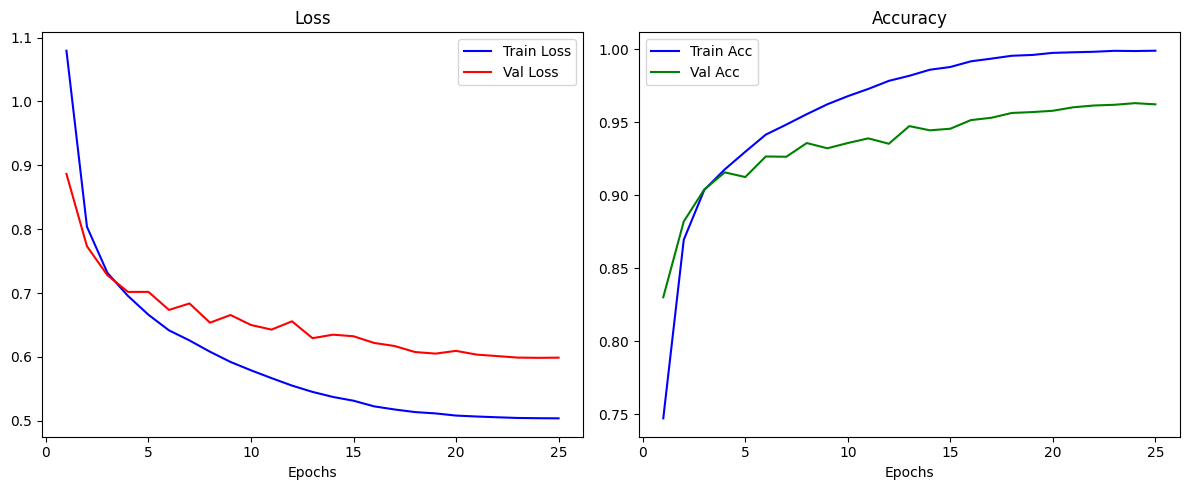

In [18]:
epochs = range(1, len(train_loss_h) + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss_h, 'b', label='Train Loss')
plt.plot(epochs, val_loss_h, 'r', label='Val Loss')
plt.title('Loss'); plt.xlabel('Epochs'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc_h, 'b', label='Train Acc')
plt.plot(epochs, val_acc_h, 'g', label='Val Acc')
plt.title('Accuracy'); plt.xlabel('Epochs'); plt.legend()
plt.tight_layout(); plt.show()

In [19]:
test_acc, test_loss = test(model, test_loader, criterion, device)
print(f'ResNet50  Test Loss: {test_loss:.4f}  Test Accuracy: {test_acc:.4f}')

ResNet50  Test Loss: 0.6122  Test Accuracy: 0.9596


## Критерии оценки
Accuracy - на тестовых данных
- $Accuracy \leq 0.67$ - 0 баллов
- $0.67 < Accuracy \leq 0.72$ - 2 балла
- $0.72 < Accuracy \leq 0.77$ - 4 балла
- $0.77 < Accuracy \leq 0.82$ - 6 баллов
- $0.82 < Accuracy \leq 0.87$ - 8 баллов
- $Accuracy > 0.87$ - 10 баллов